# Импорты

In [185]:
# %pip install matplotlib
# %pip install pymatgen

In [186]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [187]:
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.symmetry.bandstructure import HighSymmKpath

from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun

In [188]:
import warnings
import sys, os

In [ ]:
# Лицензия VASP прямо запрещает свободное распространение POTCAR-файлов
warnings.filterwarnings(
    "ignore",
    message="No POTCAR file with matching TITEL fields was found"
)

In [ ]:
pd.set_option('display.float_format', lambda v: f'{v:g}')

In [191]:
sys.path.insert(0, os.path.abspath('..'))
import QE_result_parse as qe

In [ ]:
# QE_run_02
QE_Ni_02_QERun = qe.QERun('Ni')
QE_Al_02_QERun = qe.QERun('Al')
QE_Ni3Al_02_QERun = qe.QERun('Ni3Al')

QE_Ni_02_PWIn = qe.PWIn('Ni/Ni.pw.in')
QE_Al_02_PWIn = qe.PWIn('Al/Al.pw.in')
QE_Ni3Al_02_PWIn = qe.PWIn('Ni3Al/Ni3Al.pw.in')

QE_Ni_02_PWOut = qe.PWOut('Ni/result/Ni.pw.out')
QE_Al_02_PWOut = qe.PWOut('Al/result/Al.pw.out')
QE_Ni3Al_02_PWOut = qe.PWOut('Ni3Al/result/Ni3Al.pw.out')

QE_Ni_02_xml = qe.DataFileSchema('Ni/result/data-file-schema.xml')
QE_Al_02_xml = qe.DataFileSchema('Al/result/data-file-schema.xml')
QE_Ni3Al_02_xml = qe.DataFileSchema('Ni3Al/result/data-file-schema.xml')

QE_Ni_02_nscf_PWIn = qe.PWIn('Ni/Ni_nscf.in')
QE_Al_02_nscf_PWIn = qe.PWIn('Al/Al_nscf.in')
QE_Ni3Al_02_nscf_PWIn = qe.PWIn('Ni3Al/Ni3Al_nscf.in')

QE_Ni_02_nscf_PWOut = qe.PWOut('Ni/result/Ni_nscf.out')
QE_Al_02_nscf_PWOut = qe.PWOut('Al/result/Al_nscf.out')
QE_Ni3Al_02_nscf_PWOut = qe.PWOut('Ni3Al/result/Ni3Al_nscf.out')

In [193]:
# run_03 VASP - для сравнения
Ni_03_Outcar = Outcar("../VASP_run_03/Ni/result/OUTCAR")
Al_03_Outcar = Outcar("../VASP_run_03/Al/result/OUTCAR")
Ni3Al_03_Outcar = Outcar("../VASP_run_03/Ni3Al/result/OUTCAR")

Ni_03_vasprun = Vasprun("../VASP_run_03/Ni/result/vasprun.xml")
Al_03_vasprun = Vasprun("../VASP_run_03/Al/result/vasprun.xml")
Ni3Al_03_vasprun = Vasprun("../VASP_run_03/Ni3Al/result/vasprun.xml")

Ni_03_start_structure = Structure.from_file("../VASP_run_03/Ni/POSCAR")
Al_03_start_structure = Structure.from_file("../VASP_run_03/Al/POSCAR")
Ni3Al_03_start_structure = Structure.from_file("../VASP_run_03/Ni3Al/POSCAR")

# Параметры расчёта (relax)


In [194]:
df_input_relax = pd.DataFrame({
    'Ni': QE_Ni_02_PWIn.params,
    'Al': QE_Al_02_PWIn.params,
    'Ni3Al': QE_Ni3Al_02_PWIn.params,
}).fillna('')

df_input_relax

,Ni,Al,Ni3Al
calculation,relax,relax,relax
restart_mode,from_scratch,from_scratch,from_scratch
tstress,.true.,.true.,.true.
tprnfor,.true.,.true.,.true.
outdir,./tmp_Ni,./tmp_Al,./tmp_Ni3Al
prefix,Ni,Al,Ni3Al
pseudo_dir,/content,/content,/content
starting_magnetization(1),0.6,,0
ecutwfc,80,40,80
ecutrho,500,200,500


# Параметры расчёта (NSCF)

In [195]:
df_input_nscf = pd.DataFrame({
    'Ni': QE_Ni_02_nscf_PWIn.params,
    'Al': QE_Al_02_nscf_PWIn.params,
    'Ni3Al': QE_Ni3Al_02_nscf_PWIn.params,
}).fillna('')

df_input_nscf

,Ni,Al,Ni3Al
calculation,nscf,nscf,nscf
restart_mode,from_scratch,from_scratch,from_scratch
tstress,.true.,.true.,.true.
tprnfor,.true.,.true.,.true.
outdir,./tmp_Ni,./tmp_Al,./tmp_Ni3Al
prefix,Ni,Al,Ni3Al
pseudo_dir,/content,/content,/content
starting_magnetization(1),0.6,,0
ecutwfc,80,40,80
ecutrho,500,200,500


# Проверка сходимости электронного и ионного цикла

In [196]:
df_converged = pd.DataFrame({
    'relax': [QE_Ni_02_PWOut.converged, QE_Al_02_PWOut.converged, QE_Ni3Al_02_PWOut.converged],
    'nscf': [QE_Ni_02_nscf_PWOut.converged, QE_Al_02_nscf_PWOut.converged, QE_Ni3Al_02_nscf_PWOut.converged],
    'bfgs_steps': [QE_Ni_02_PWOut.bfgs_steps, QE_Al_02_PWOut.bfgs_steps, QE_Ni3Al_02_PWOut.bfgs_steps],
}, index=['Ni', 'Al', 'Ni3Al'])

df_converged

,relax,nscf,bfgs_steps
Ni,True,True,0
Al,True,True,0
Ni3Al,True,True,0


> Все шесть расчетов завершились штатно и сошлись. Стартовые структуры (fcc Ni, fcc Al, L1₂ Ni₃Al) заданы в позициях высокой симметрии, где силы обязаны быть нулевыми по симметрии, поэтому релаксация потребовала минимум итераций.

## Электронный цикл

In [197]:
QE_Ni_02_relax_scf = QE_Ni_02_PWOut.scf_cycle(units='Ry')
QE_Al_02_relax_scf = QE_Al_02_PWOut.scf_cycle(units='Ry')
QE_Ni3Al_02_relax_scf = QE_Ni3Al_02_PWOut.scf_cycle(units='Ry')

QE_Ni_02_relax_ethr = QE_Ni_02_relax_scf['ethr_Ry']
QE_Al_02_relax_ethr = QE_Al_02_relax_scf['ethr_Ry']
QE_Ni3Al_02_relax_ethr = QE_Ni3Al_02_relax_scf['ethr_Ry']

QE_Ni_02_relax_E = QE_Ni_02_relax_scf['E_Ry']
QE_Al_02_relax_E = QE_Al_02_relax_scf['E_Ry']
QE_Ni3Al_02_relax_E = QE_Ni3Al_02_relax_scf['E_Ry']

In [ ]:
data = []
max_len = max(len(QE_Ni_02_relax_ethr), len(QE_Al_02_relax_ethr), len(QE_Ni3Al_02_relax_ethr))
for i in range(max_len):
    row = {'Итерация': i + 1}
    if i < len(QE_Ni_02_relax_ethr):
        row['Ni ethr (Ry)'] = QE_Ni_02_relax_ethr[i]
    if i < len(QE_Al_02_relax_ethr):
        row['Al ethr (Ry)'] = QE_Al_02_relax_ethr[i]
    if i < len(QE_Ni3Al_02_relax_ethr):
        row['Ni3Al ethr (Ry)'] = QE_Ni3Al_02_relax_ethr[i]
    data.append(row)

df_relax_scf_ethr = pd.DataFrame(data)
df_relax_scf_ethr.style.hide(axis='index').format({
    col: '{:.10f}' for col in df_relax_scf_ethr.columns if 'ethr' in col
})

Итерация,Ni ethr (Ry),Al ethr (Ry),Ni3Al ethr (Ry)
1,0.0100000000,0.0100000000,0.0100000000
2,0.0100000000,0.0001800000,0.0003320000
3,0.0044100000,0.0001790000,0.0003350000
4,0.0005330000,0.0000465000,0.0002050000
5,0.0000959000,0.0000001360,0.0000143000
6,0.0000751000,0.0000000014,0.0000003450
7,0.0000012300,0.0000000002,0.0000000852
8,0.0000000238,nan,0.0000000115
9,0.0000000066,nan,0.0000000115
10,0.0000000009,nan,0.0000000003


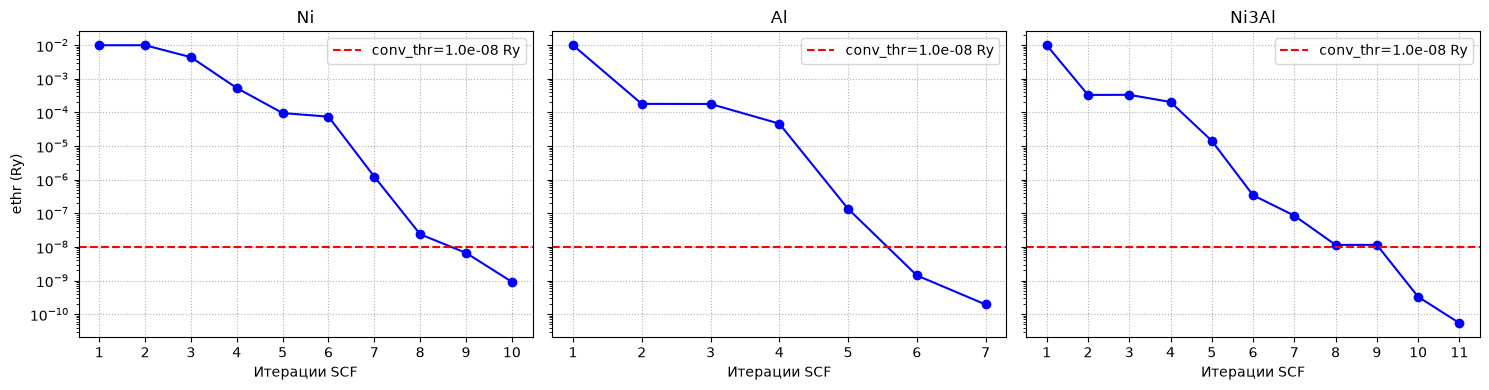

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ethr_data, pw_in, name in zip(axes,
                                      [QE_Ni_02_relax_ethr, QE_Al_02_relax_ethr, QE_Ni3Al_02_relax_ethr],
                                      [QE_Ni_02_PWIn, QE_Al_02_PWIn, QE_Ni3Al_02_PWIn],
                                      ['Ni', 'Al', 'Ni3Al']):
    conv_thr_Ry = pw_in.conv_thr(units='Ry')
    ax.plot(range(1, len(ethr_data) + 1), ethr_data, 'o-', color='b')
    ax.axhline(conv_thr_Ry, color='r', linestyle='--', label=f'conv_thr={conv_thr_Ry:.1e} Ry')
    ax.set_yscale('log')
    ax.set_xlabel('Итерации SCF')
    ax.set_title(name)
    ax.grid(linestyle=':')
    ax.legend()
    max_iter = len(ethr_data)
    ax.set_xticks(range(1, max_iter + 1))

axes[0].set_ylabel('ethr (Ry)')
plt.tight_layout()
plt.show()

## Ионный цикл

In [ ]:
data_ion_forces = []
for name, run in [('Ni', QE_Ni_02_QERun), ('Al', QE_Al_02_QERun), ('Ni3Al', QE_Ni3Al_02_QERun)]:
    df_f = run.ion_forces(units='eV/A')
    for k in range(len(df_f)):
        data_ion_forces.append({'Система': name,
                                'Ионный шаг': int(df_f['Ионный шаг'].iat[k]) + 1,
                                '|F_max| (эВ/Å)': df_f['|F_max| (эВ/Å)'].iat[k]})

df_relax_ion_forces = pd.DataFrame(data_ion_forces)
df_relax_ion_forces

,Система,Ионный шаг,|F_max| (эВ/Å)
0,Ni,1,0
1,Al,1,0
2,Ni3Al,1,0


> **Примечание по ионной сходимости**     
> Стартовые структуры (fcc Ni, fcc Al, L1₂ Ni₃Al) заданы в позициях высокой симметрии, где силы обязаны быть нулевыми по симметрии. Расчёт сошёлся без движения ионов.

# Кристаллографические параметры

In [201]:
# [QE_run_02_relax] 
QE_Ni_02_relax_start_structure = QE_Ni_02_PWIn.structure
QE_Al_02_relax_start_structure = QE_Al_02_PWIn.structure
QE_Ni3Al_02_relax_start_structure = QE_Ni3Al_02_PWIn.structure

# [QE_run_02_relax] Начальный параметр решетки
QE_Ni_02_relax_a = QE_Ni_02_relax_start_structure.lattice.a
QE_Al_02_relax_a = QE_Al_02_relax_start_structure.lattice.a
QE_Ni3Al_02_relax_a = QE_Ni3Al_02_relax_start_structure.lattice.a

# [QE_run_02_relax] Начальный объем
QE_Ni_02_relax_volume = QE_Ni_02_relax_start_structure.volume
QE_Al_02_relax_volume = QE_Al_02_relax_start_structure.volume
QE_Ni3Al_02_relax_volume = QE_Ni3Al_02_relax_start_structure.volume

# [QE_run_02_relax] Пространственная группа
QE_Ni_02_relax_Space_Group = SpacegroupAnalyzer(QE_Ni_02_relax_start_structure, 0.1).get_space_group_symbol()
QE_Al_02_relax_Space_Group = SpacegroupAnalyzer(QE_Al_02_relax_start_structure, 0.1).get_space_group_symbol()
QE_Ni3Al_02_relax_Space_Group = SpacegroupAnalyzer(QE_Ni3Al_02_relax_start_structure, 0.1).get_space_group_symbol()

# [QE_run_02_relax] Оптимизированные структуры
QE_Ni_02_relax_opt_structure = Structure.from_file('Ni/result/Ni_opt.cif')
QE_Al_02_relax_opt_structure = Structure.from_file('Al/result/Al_opt.cif')
QE_Ni3Al_02_relax_opt_structure = Structure.from_file('Ni3Al/result/Ni3Al_opt.cif')

# [QE_run_02_relax] Параметр решетки после релаксации
QE_Ni_02_relax_opt_a = QE_Ni_02_relax_opt_structure.lattice.a
QE_Al_02_relax_opt_a = QE_Al_02_relax_opt_structure.lattice.a
QE_Ni3Al_02_relax_opt_a = QE_Ni3Al_02_relax_opt_structure.lattice.a

In [202]:
# [QE_run_02_nscf] 
QE_Ni_02_nscf_start_structure = QE_Ni_02_nscf_PWIn.structure
QE_Al_02_nscf_start_structure = QE_Al_02_nscf_PWIn.structure
QE_Ni3Al_02_nscf_start_structure = QE_Ni3Al_02_nscf_PWIn.structure

# [QE_run_02_nscf] Начальный параметр решетки
QE_Ni_02_nscf_a = QE_Ni_02_nscf_start_structure.lattice.a
QE_Al_02_nscf_a = QE_Al_02_nscf_start_structure.lattice.a
QE_Ni3Al_02_nscf_a = QE_Ni3Al_02_nscf_start_structure.lattice.a

# [QE_run_02_nscf] Начальный объем
QE_Ni_02_nscf_volume = QE_Ni_02_nscf_start_structure.volume
QE_Al_02_nscf_volume = QE_Al_02_nscf_start_structure.volume
QE_Ni3Al_02_nscf_volume = QE_Ni3Al_02_nscf_start_structure.volume

In [203]:
# [VASP_run_03] Начальный параметр решетки
VASP_Ni_a_03 = Ni_03_start_structure.lattice.a
VASP_Al_a_03 = Al_03_start_structure.lattice.a
VASP_Ni3Al_a_03 = Ni3Al_03_start_structure.lattice.a

# [VASP_run_03] Начальный объем
VASP_Ni_volume_03 = Ni_03_start_structure.volume
VASP_Al_volume_03 = Al_03_start_structure.volume
VASP_Ni3Al_volume_03 = Ni3Al_03_start_structure.volume

In [ ]:
data_crystal = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'Группа (QE/relax)': [QE_Ni_02_relax_Space_Group, QE_Al_02_relax_Space_Group, QE_Ni3Al_02_relax_Space_Group],
    'a старт. (Å) (QE/relax)': [QE_Ni_02_relax_a, QE_Al_02_relax_a, QE_Ni3Al_02_relax_a],
    'a оптим. (Å) (QE/relax)': [QE_Ni_02_relax_opt_a, QE_Al_02_relax_opt_a, QE_Ni3Al_02_relax_opt_a],
    'a старт. (Å) (QE/nscf)': [QE_Ni_02_nscf_a, QE_Al_02_nscf_a, QE_Ni3Al_02_nscf_a],
    'a старт. (Å) (VASP)': [VASP_Ni_a_03, VASP_Al_a_03, VASP_Ni3Al_a_03],
    'V старт. (Å³) (QE/relax)': [QE_Ni_02_relax_volume, QE_Al_02_relax_volume, QE_Ni3Al_02_relax_volume],
    'V старт. (Å³) (QE/nscf)': [QE_Ni_02_nscf_volume, QE_Al_02_nscf_volume, QE_Ni3Al_02_nscf_volume],
    'V старт. (Å³) (VASP)': [VASP_Ni_volume_03, VASP_Al_volume_03, VASP_Ni3Al_volume_03],
}

df_crystal = pd.DataFrame(data_crystal)
df_crystal

,Система,Группа (QE/relax),a старт. (Å) (QE/relax),a оптим. (Å) (QE/relax),a старт. (Å) (QE/nscf),a старт. (Å) (VASP),V старт. (Å³) (QE/relax),V старт. (Å³) (QE/nscf),V старт. (Å³) (VASP)
0,Ni,Fm-3m,3.52,3.52,3.52,3.52,43.6142,43.6142,43.6142
1,Al,Fm-3m,4.05,4.05,4.05,4.05,66.4301,66.4301,66.4301
2,Ni3Al,Pm-3m,3.57,3.57,3.57,3.57,45.4993,45.4993,45.4993


> **Примечание о сравнении с run_03**                  
> Сравнение с результатами каталога `run_03` выполнено для верификации расчётов. В `run_03` использовался код VASP с параметром `ISIF = 2`, что означает релаксацию только ионных позиций при фиксированных параметрах элементарной ячейки (объём и форма остаются неизменными). В представленных расчётах Quantum ESPRESSO используется режим `calculation = 'relax'` (не `vc-relax` который соответствует `ISIF=3`), который также выполняет релаксацию исключительно атомных координат, без изменения решётки. Параметр `cell_dynamics = 'bfgs'` в данном случае задаёт алгоритм оптимизации ионных позиций, но не влияет на ячейку.  

# Магнитный момент

In [ ]:
# Суммарные магнитные моменты из QE (run_02)
QE_Ni_02_relax_total_mag = QE_Ni_02_QERun.total_mag
QE_Al_02_relax_total_mag = QE_Al_02_QERun.total_mag
QE_Ni3Al_02_relax_total_mag = QE_Ni3Al_02_QERun.total_mag

df_mag = pd.DataFrame({
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'Магн. момент (μB) (QE/relax)': [QE_Ni_02_relax_total_mag, QE_Al_02_relax_total_mag, QE_Ni3Al_02_relax_total_mag],
})
df_mag

,Система,Магн. момент (μB) (QE/relax)
0,Ni,2.47
1,Al,0
2,Ni3Al,-0



**из входного файла для Ni:**
```
nspin = 2
starting_magnetization(1) = 0.6
```

Значение `total_mag` из ячейки выше показывает, что система не только сохранила заданную намагниченность, но и увеличила её за счёт обменного взаимодействия (≈0.6 µ_B на атом Ni). Это подтверждает устойчивость ферромагнитного состояния в чистом Ni.



**из входного файла для Ni3Al:**
```
nspin = 2
starting_magnetization(1) = 0.0
starting_magnetization(2) = 0.0
```

Итоговая суммарная намагниченность (см. ячейку выше) практически равна нулю — спонтанная спиновая поляризация в данной структуре отсутствует. Это согласуется с литературными данными для объёмного Ni3Al со структурой L1₂: он является слабомагнитным или парамагнитным при комнатных условиях.


# Полные энергии и энтальпия образования Ni3Al

In [206]:
QE_Ni_02_relax_TOTEN = QE_Ni_02_QERun.etot(units='eV')
QE_Al_02_relax_TOTEN = QE_Al_02_QERun.etot(units='eV')
QE_Ni3Al_02_relax_TOTEN = QE_Ni3Al_02_QERun.etot(units='eV')

print("Ni:", QE_Ni_02_relax_TOTEN, "эВ")
print("Al:", QE_Al_02_relax_TOTEN, "эВ")
print("Ni3Al:", QE_Ni3Al_02_relax_TOTEN, "эВ")

Ni: -23355.94640299308 эВ
Al: -2149.865753663663 эВ
Ni3Al: -18056.12528116648 эВ


In [207]:
# Изменение энтальпии образования, выраженное в электрон-вольтах на одну формульную единицу
QE_relax_dH_form_02_ev_per_fu = QE_Ni3Al_02_relax_TOTEN - (0.75*QE_Ni_02_relax_TOTEN + 0.25*QE_Al_02_relax_TOTEN)

# Изменение энтальпии образования, выраженное в килоджоулях на моль формульных единиц
QE_relax_dH_form_02_kJ_per_mol_fu = QE_relax_dH_form_02_ev_per_fu * qe.EV_TO_KJ_PER_MOL

# Изменение энтальпии образования, выраженное в килоджоулях на моль атомов
QE_relax_dH_form_02_kJ_per_mol_atom = QE_relax_dH_form_02_kJ_per_mol_fu / 4

print(QE_relax_dH_form_02_ev_per_fu, "эВ")
print(QE_relax_dH_form_02_kJ_per_mol_fu, "кДж/моль формульных единиц")
print(QE_relax_dH_form_02_kJ_per_mol_atom, "кДж/моль атомов")

-1.699040505758603 эВ
-163.93192319811882 кДж/моль формульных единиц
-40.982980799529706 кДж/моль атомов


# K-точки

In [ ]:
# Приводим к примитивной ячейке для корректного получения точек высокой симметрии (зона Бриллюэна задана для примитивной ячейки)
QE_Ni_02_prim = SpacegroupAnalyzer(QE_Ni_02_nscf_start_structure).get_primitive_standard_structure()
QE_Al_02_prim = SpacegroupAnalyzer(QE_Al_02_nscf_start_structure).get_primitive_standard_structure()
QE_Ni3Al_02_prim = SpacegroupAnalyzer(QE_Ni3Al_02_nscf_start_structure).get_primitive_standard_structure()

# K-точки высокой симметрии
QE_Ni_02_hs_points = ', '.join(HighSymmKpath(QE_Ni_02_prim).kpath['kpoints'].keys())
QE_Al_02_hs_points = ', '.join(HighSymmKpath(QE_Al_02_prim).kpath['kpoints'].keys())
QE_Ni3Al_02_hs_points = ', '.join(HighSymmKpath(QE_Ni3Al_02_prim).kpath['kpoints'].keys())

In [ ]:
# K-сетка VASP из уже загруженных vasprun.xml (ячейка импорта)
VASP_Ni_N_KPOINTS_03 = len(Ni_03_vasprun.actual_kpoints)
VASP_Al_N_KPOINTS_03 = len(Al_03_vasprun.actual_kpoints)
VASP_Ni3Al_N_KPOINTS_03 = len(Ni3Al_03_vasprun.actual_kpoints)

# Размерность k-сетки (kpts[0]) из vasprun.xml
VASP_Ni_kx_03, VASP_Ni_ky_03, VASP_Ni_kz_03 = Ni_03_vasprun.kpoints.kpts[0]
VASP_Al_kx_03, VASP_Al_ky_03, VASP_Al_kz_03 = Al_03_vasprun.kpoints.kpts[0]
VASP_Ni3Al_kx_03, VASP_Ni3Al_ky_03, VASP_Ni3Al_kz_03 = Ni3Al_03_vasprun.kpoints.kpts[0]

# K-сетка
VASP_Ni_kmesh_03 = f"{VASP_Ni_kx_03}×{VASP_Ni_ky_03}×{VASP_Ni_kz_03}"
VASP_Al_kmesh_03 = f"{VASP_Al_kx_03}×{VASP_Al_ky_03}×{VASP_Al_kz_03}"
VASP_Ni3Al_kmesh_03 = f"{VASP_Ni3Al_kx_03}×{VASP_Ni3Al_ky_03}×{VASP_Ni3Al_kz_03}"

In [ ]:
# K-сетка QE (relax) из входных файлов .pw.in
QE_Ni_02_relax_kx, QE_Ni_02_relax_ky, QE_Ni_02_relax_kz = QE_Ni_02_PWIn.kmesh
QE_Al_02_relax_kx, QE_Al_02_relax_ky, QE_Al_02_relax_kz = QE_Al_02_PWIn.kmesh
QE_Ni3Al_02_relax_kx, QE_Ni3Al_02_relax_ky, QE_Ni3Al_02_relax_kz = QE_Ni3Al_02_PWIn.kmesh

# K-сетка
QE_Ni_02_relax_kmesh = f"{QE_Ni_02_relax_kx}×{QE_Ni_02_relax_ky}×{QE_Ni_02_relax_kz}"
QE_Al_02_relax_kmesh = f"{QE_Al_02_relax_kx}×{QE_Al_02_relax_ky}×{QE_Al_02_relax_kz}"
QE_Ni3Al_02_relax_kmesh = f"{QE_Ni3Al_02_relax_kx}×{QE_Ni3Al_02_relax_ky}×{QE_Ni3Al_02_relax_kz}"

In [ ]:
# MP-сетка nscf из входных файлов .pw.in
QE_Ni_02_nscf_kx, QE_Ni_02_nscf_ky, QE_Ni_02_nscf_kz = QE_Ni_02_nscf_PWIn.kmesh
QE_Al_02_nscf_kx, QE_Al_02_nscf_ky, QE_Al_02_nscf_kz = QE_Al_02_nscf_PWIn.kmesh
QE_Ni3Al_02_nscf_kx, QE_Ni3Al_02_nscf_ky, QE_Ni3Al_02_nscf_kz = QE_Ni3Al_02_nscf_PWIn.kmesh

# K-сетка
QE_Ni_02_nscf_kmesh = f"{QE_Ni_02_nscf_kx}×{QE_Ni_02_nscf_ky}×{QE_Ni_02_nscf_kz}"
QE_Al_02_nscf_kmesh = f"{QE_Al_02_nscf_kx}×{QE_Al_02_nscf_ky}×{QE_Al_02_nscf_kz}"
QE_Ni3Al_02_nscf_kmesh = f"{QE_Ni3Al_02_nscf_kx}×{QE_Ni3Al_02_nscf_ky}×{QE_Ni3Al_02_nscf_kz}"

In [211]:
data_kpoints = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'K-сетка (QE/relax)': [QE_Ni_02_relax_kmesh, QE_Al_02_relax_kmesh, QE_Ni3Al_02_relax_kmesh],
    'K-сетка (QE/nscf)': [QE_Ni_02_nscf_kmesh, QE_Al_02_nscf_kmesh, QE_Ni3Al_02_nscf_kmesh],
    'K-сетка (VASP)': [VASP_Ni_kmesh_03, VASP_Al_kmesh_03, VASP_Ni3Al_kmesh_03],
    'Высокосимм. точки': [QE_Ni_02_hs_points, QE_Al_02_hs_points, QE_Ni3Al_02_hs_points],
}

df_kpoints = pd.DataFrame(data_kpoints)
df_kpoints

,Система,K-сетка (QE/relax),K-сетка (QE/nscf),K-сетка (VASP),Высокосимм. точки
0,Ni,8×8×8,18×18×18,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,8×8×8,16×16×16,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,8×8×8,18×18×18,18×18×18,"\Gamma, X, R, M"


# Плотность состояний (DOS)

In [ ]:
QE_Ni_02_relax_nelect = QE_Ni_02_QERun.nelec
QE_Al_02_relax_nelect = QE_Al_02_QERun.nelec
QE_Ni3Al_02_relax_nelect = QE_Ni3Al_02_QERun.nelec

# Число электронов
print(f"Ni:  {QE_Ni_02_relax_nelect} электронов")
print(f"Al:  {QE_Al_02_relax_nelect} электронов")
print(f"Ni3Al: {QE_Ni3Al_02_relax_nelect} электронов")

Ni:  72 электронов
Al:  12 электронов
Ni3Al: 57 электронов


In [213]:
QE_Ni_02_nscf_efermi = QE_Ni_02_nscf_PWOut.efermi(units='eV')
QE_Al_02_nscf_efermi = QE_Al_02_nscf_PWOut.efermi(units='eV')
QE_Ni3Al_02_nscf_efermi = QE_Ni3Al_02_nscf_PWOut.efermi(units='eV')

# Полная DOS
QE_Ni_02_dos_E, QE_Ni_02_dos_up, QE_Ni_02_dos_dn = qe.load_tdos('Ni/result/Ni.pdos_tot')
QE_Al_02_dos_E, QE_Al_02_dos_up, QE_Al_02_dos_dn = qe.load_tdos('Al/result/Al.pdos_tot')
QE_Ni3Al_02_dos_E, QE_Ni3Al_02_dos_up, QE_Ni3Al_02_dos_dn = qe.load_tdos('Ni3Al/result/Ni3Al.pdos_tot')

# Полные DOS-массивы: столбцы (E, dos_up, dos_dn)
QE_Ni_02_dos_data = np.column_stack([QE_Ni_02_dos_E, QE_Ni_02_dos_up, QE_Ni_02_dos_dn])
QE_Al_02_dos_data = np.column_stack([QE_Al_02_dos_E, QE_Al_02_dos_up])
QE_Ni3Al_02_dos_data = np.column_stack([QE_Ni3Al_02_dos_E, QE_Ni3Al_02_dos_up, QE_Ni3Al_02_dos_dn])

# E (eV)  dosup(E)   dosdw(E)
QE_Ni_02_dos_energy = QE_Ni_02_dos_data[:, 0]
QE_Ni_02_dos_density = QE_Ni_02_dos_data[:, 1] + QE_Ni_02_dos_data[:, 2]

# E (eV)  dos(E)
QE_Al_02_dos_energy = QE_Al_02_dos_data[:, 0]
QE_Al_02_dos_density = QE_Al_02_dos_data[:, 1]

# E (eV)  dosup(E)   dosdw(E)
QE_Ni3Al_02_dos_energy = QE_Ni3Al_02_dos_data[:, 0]
QE_Ni3Al_02_dos_density = QE_Ni3Al_02_dos_data[:, 1] + QE_Ni3Al_02_dos_data[:, 2]

In [214]:
# Энергии Ферми из VASP run_03
Ni_03_efermi = Ni_03_vasprun.complete_dos.efermi
Al_03_efermi = Al_03_vasprun.complete_dos.efermi
Ni3Al_03_efermi = Ni3Al_03_vasprun.complete_dos.efermi

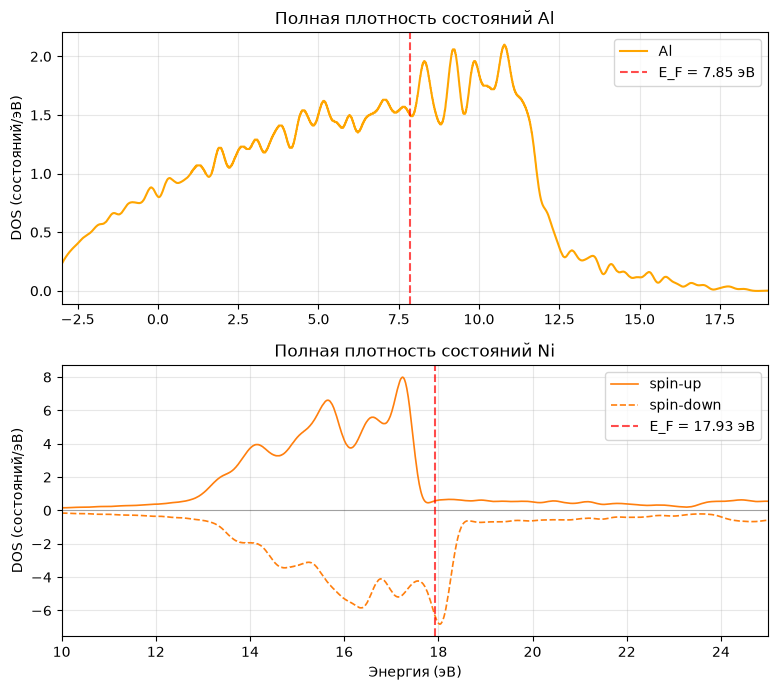

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7))

# TDOS Al (неспин-поляризован)
axes[0].plot(QE_Al_02_dos_energy, QE_Al_02_dos_density, color='orange', label='Al')
axes[0].axvline(QE_Al_02_nscf_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {QE_Al_02_nscf_efermi:.2f} эВ')
axes[0].set_xlim(-3, 19)
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Полная плотность состояний Al')

# TDOS Ni (спин-поляризован)
axes[1].plot(QE_Ni_02_dos_energy, QE_Ni_02_dos_up, '-', label='spin-up', color='tab:orange', linewidth=1.2)
axes[1].plot(QE_Ni_02_dos_energy, -QE_Ni_02_dos_dn, '--', label='spin-down', color='tab:orange', linewidth=1.2)
axes[1].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[1].axvline(QE_Ni_02_nscf_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {QE_Ni_02_nscf_efermi:.2f} эВ')
axes[1].set_xlim(10, 25)
axes[1].set_xlabel('Энергия (эВ)')
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Полная плотность состояний Ni')

plt.tight_layout()
plt.show()

# Парциальная плотность состояний (PDOS, projwfc.x)

In [ ]:
QE_Ni3Al_02_element_dos = qe.load_element_dos('Ni3Al/result', 'Ni3Al')
QE_Ni3Al_02_pdos_Al = QE_Ni3Al_02_element_dos['Al']
QE_Ni3Al_02_pdos_Ni = QE_Ni3Al_02_element_dos['Ni']

QE_Ni3Al_02_dos_up_Al = QE_Ni3Al_02_pdos_Al['up']
QE_Ni3Al_02_dos_dn_Al = QE_Ni3Al_02_pdos_Al['dn']
QE_Ni3Al_02_dos_up_Ni = QE_Ni3Al_02_pdos_Ni['up']
QE_Ni3Al_02_dos_dn_Ni = QE_Ni3Al_02_pdos_Ni['dn']

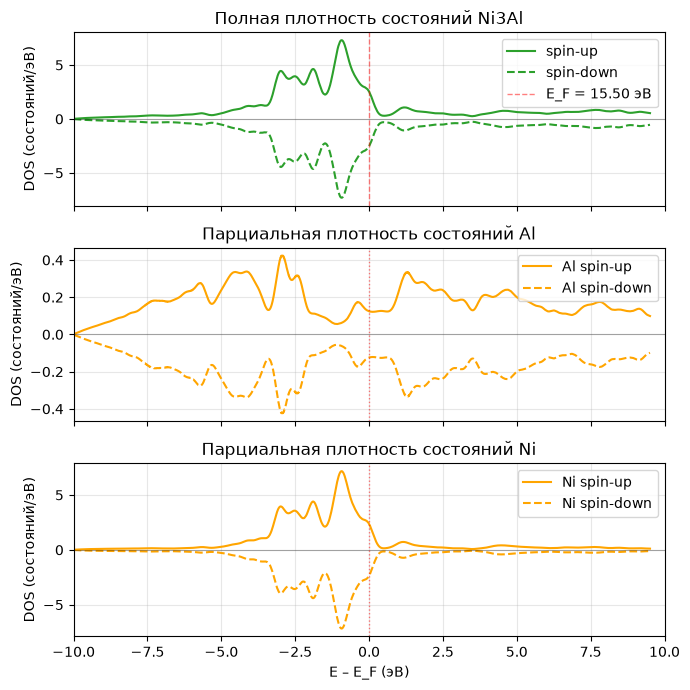

In [217]:
# Сдвиг энергии относительно уровня Ферми
e_total = QE_Ni3Al_02_dos_energy - QE_Ni3Al_02_nscf_efermi
e_al = QE_Ni3Al_02_pdos_Al['energy'] - QE_Ni3Al_02_nscf_efermi
e_ni = QE_Ni3Al_02_pdos_Ni['energy'] - QE_Ni3Al_02_nscf_efermi

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# TDOS Ni3Al
axes[0].plot(e_total, QE_Ni3Al_02_dos_up, '-', label='spin-up', color='tab:green', linewidth=1.5)
axes[0].plot(e_total, -QE_Ni3Al_02_dos_dn, '--', label='spin-down', color='tab:green', linewidth=1.5)
axes[0].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[0].axvline(0, color='r', linestyle='--', alpha=0.5, linewidth=1, label=f'E_F = {QE_Ni3Al_02_nscf_efermi:.2f} эВ')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].set_title('Полная плотность состояний Ni3Al')
axes[0].grid(alpha=0.3)
axes[0].legend()

# PDOS Al
axes[1].plot(e_al, QE_Ni3Al_02_dos_up_Al, '-', label='Al spin-up', color='orange', linewidth=1.5)
axes[1].plot(e_al, -QE_Ni3Al_02_dos_dn_Al, '--', label='Al spin-down', color='orange', linewidth=1.5)
axes[1].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[1].axvline(0, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].set_title('Парциальная плотность состояний Al')
axes[1].grid(alpha=0.3)
axes[1].legend()

# PDOS Ni
axes[2].plot(e_ni, QE_Ni3Al_02_dos_up_Ni, '-', label='Ni spin-up', color='orange', linewidth=1.5)
axes[2].plot(e_ni, -QE_Ni3Al_02_dos_dn_Ni, '--', label='Ni spin-down', color='orange', linewidth=1.5)
axes[2].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[2].axvline(0, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[2].set_xlabel('E – E_F (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].set_title('Парциальная плотность состояний Ni')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.xlim(-10, 10)
plt.tight_layout()
plt.show()

# Сводная таблица

In [ ]:
df_summary = pd.DataFrame([
    {'Система': 'Ni', 'E_F (эВ) (QE/relax)': QE_Ni_02_nscf_efermi, 'Магн. момент (μB) (QE/relax)': QE_Ni_02_relax_total_mag,
     'Полная энергия (эВ) (QE/relax)': QE_Ni_02_relax_TOTEN, 'ΔH_обр (кДж/моль атомов) (QE/relax)': float('nan')},
    {'Система': 'Al', 'E_F (эВ) (QE/relax)': QE_Al_02_nscf_efermi, 'Магн. момент (μB) (QE/relax)': QE_Al_02_relax_total_mag,
     'Полная энергия (эВ) (QE/relax)': QE_Al_02_relax_TOTEN, 'ΔH_обр (кДж/моль атомов) (QE/relax)': float('nan')},
    {'Система': 'Ni3Al', 'E_F (эВ) (QE/relax)': QE_Ni3Al_02_nscf_efermi, 'Магн. момент (μB) (QE/relax)': QE_Ni3Al_02_relax_total_mag,
     'Полная энергия (эВ) (QE/relax)': QE_Ni3Al_02_relax_TOTEN, 'ΔH_обр (кДж/моль атомов) (QE/relax)': QE_relax_dH_form_02_kJ_per_mol_atom},
])

df_summary = df_summary.merge(df_crystal)
df_summary = df_summary.merge(df_kpoints)
df_summary = df_summary.drop(columns=[c for c in df_summary.columns if 'VASP' in c])

df_summary

,Система,E_F (эВ) (QE/relax),Магн. момент (μB) (QE/relax),Полная энергия (эВ) (QE/relax),ΔH_обр (кДж/моль атомов) (QE/relax),Группа (QE/relax),a старт. (Å) (QE/relax),a оптим. (Å) (QE/relax),a старт. (Å) (QE/nscf),V старт. (Å³) (QE/relax),V старт. (Å³) (QE/nscf),K-сетка (QE/relax),K-сетка (QE/nscf),Высокосимм. точки
0,Ni,17.9316,2.47,-23355.9,NaN,Fm-3m,3.52,3.52,3.52,43.6142,43.6142,8×8×8,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,7.8501,0,-2149.87,NaN,Fm-3m,4.05,4.05,4.05,66.4301,66.4301,8×8×8,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,15.4956,-0,-18056.1,-40.983,Pm-3m,3.57,3.57,3.57,45.4993,45.4993,8×8×8,18×18×18,"\Gamma, X, R, M"


# Сравнение QE (run_02) vs VASP (run_03)

In [ ]:
# Полные энергии из VASP run_03
VASP_Ni_TOTEN_03 = Ni_03_Outcar.final_energy
VASP_Al_TOTEN_03 = Al_03_Outcar.final_energy
VASP_Ni3Al_TOTEN_03 = Ni3Al_03_Outcar.final_energy

# Магнитные моменты из VASP run_03
VASP_Ni_total_mag_03 = Ni_03_Outcar.total_mag
VASP_Al_total_mag_03 = Al_03_Outcar.total_mag
VASP_Ni3Al_total_mag_03 = Ni3Al_03_Outcar.total_mag

# Энергия образования из VASP run_03
VASP_dH_form_03_ev_per_fu = VASP_Ni3Al_TOTEN_03 - (0.75*VASP_Ni_TOTEN_03 + 0.25*VASP_Al_TOTEN_03)
VASP_dH_form_03_kJ_per_mol_atom = VASP_dH_form_03_ev_per_fu * qe.EV_TO_KJ_PER_MOL / 4

In [ ]:
comparison_data = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'E (эВ) (QE/relax)': [QE_Ni_02_relax_TOTEN, QE_Al_02_relax_TOTEN, QE_Ni3Al_02_relax_TOTEN],
    'E (эВ) (VASP)': [VASP_Ni_TOTEN_03, VASP_Al_TOTEN_03, VASP_Ni3Al_TOTEN_03],
    'E_F (эВ) (QE/nscf)': [QE_Ni_02_nscf_efermi, QE_Al_02_nscf_efermi, QE_Ni3Al_02_nscf_efermi],
    'E_F (эВ) (VASP)': [Ni_03_efermi, Al_03_efermi, Ni3Al_03_efermi],
    'a старт. (Å) (QE/nscf)': [QE_Ni_02_nscf_a, QE_Al_02_nscf_a, QE_Ni3Al_02_nscf_a],
    'a старт. (Å) (VASP)': [VASP_Ni_a_03, VASP_Al_a_03, VASP_Ni3Al_a_03],
    'Магн. момент (QE/relax)': [QE_Ni_02_relax_total_mag, QE_Al_02_relax_total_mag, QE_Ni3Al_02_relax_total_mag],
    'Магн. момент (VASP)': [VASP_Ni_total_mag_03, VASP_Al_total_mag_03, VASP_Ni3Al_total_mag_03],
    'ΔM (μB)': [QE_Ni_02_relax_total_mag - VASP_Ni_total_mag_03, None, QE_Ni3Al_02_relax_total_mag - VASP_Ni3Al_total_mag_03],
    'ΔH_обр (кДж/моль атомов) (QE/relax)': [None, None, QE_relax_dH_form_02_kJ_per_mol_atom],
    'ΔH_обр (кДж/моль атомов) (VASP)': [None, None, VASP_dH_form_03_kJ_per_mol_atom],
    'Δ(ΔH_обр) (кДж/моль атомов)': [None, None, QE_relax_dH_form_02_kJ_per_mol_atom - VASP_dH_form_03_kJ_per_mol_atom],
}

df_compare = pd.DataFrame(comparison_data).fillna('—')
df_compare

,Система,E (эВ) (QE/relax),E (эВ) (VASP),E_F (эВ) (QE/nscf),E_F (эВ) (VASP),a старт. (Å) (QE/nscf),a старт. (Å) (VASP),Магн. момент (QE/relax),Магн. момент (VASP),ΔM (μB),ΔH_обр (кДж/моль атомов) (QE/relax),ΔH_обр (кДж/моль атомов) (VASP),Δ(ΔH_обр) (кДж/моль атомов)
0,Ni,-23355.9,-22.2896,17.9316,4.77304,3.52,3.52,2.47,2.504,-0.034001,—,—,—
1,Al,-2149.87,-14.984,7.8501,7.9392,4.05,4.05,0,—,—,—,—,—
2,Ni3Al,-18056.1,-22.1966,15.4956,6.06291,3.57,3.57,-0,0.0011988,-0.0011988,-40.983,-41.8117,0.828685


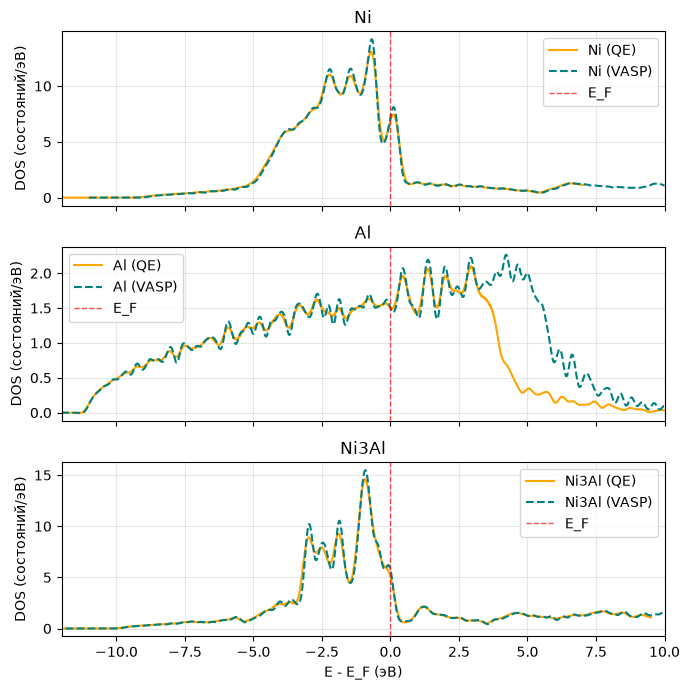

In [ ]:
VASP_systems_03 = [
    (Ni_03_vasprun, Ni_03_efermi, 'Ni'),
    (Al_03_vasprun, Al_03_efermi, 'Al'),
    (Ni3Al_03_vasprun, Ni3Al_03_efermi, 'Ni3Al')
]

QE_systems_02 = [
    (QE_Ni_02_dos_energy, QE_Ni_02_dos_density, QE_Ni_02_nscf_efermi, 'Ni'),
    (QE_Al_02_dos_energy, QE_Al_02_dos_density, QE_Al_02_nscf_efermi, 'Al'),
    (QE_Ni3Al_02_dos_energy, QE_Ni3Al_02_dos_density, QE_Ni3Al_02_nscf_efermi, 'Ni3Al')
]

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

for i, ((v03, ef03, label), (qe_e, qe_d, qef, _)) in enumerate(zip(VASP_systems_03, QE_systems_02)):
    dos03 = sum(v03.complete_dos.densities.values())
    e_qe = qe_e - qef
    e_vasp = v03.complete_dos.energies - ef03

    axes[i].plot(e_qe, qe_d, color='orange', label=f'{label} (QE)')
    axes[i].plot(e_vasp, dos03, color='teal', linestyle='--', label=f'{label} (VASP)')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=1, label='E_F')
    axes[i].set_ylabel('DOS (состояний/эВ)')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].set_title(label)

axes[2].set_xlabel('E - E_F (эВ)')

plt.xlim(-12, 10)
plt.tight_layout()
plt.show()